
<div style="border:solid green 2px; padding: 20px">

👋 **¡Hola! Soy Dot, tu revisor de IA.**

He completado la primera revisión de tu código. A continuación, encontrarás mis comentarios y sugerencias de mejora.

**¿Qué debes hacer ahora?**

1. **Revisar:** Lee mis comentarios en el notebook más abajo.
2. **Decidir:**
* **¿Estás de acuerdo con el feedback?** ¡Genial! Actualiza tu código según las sugerencias.
* **¿No estás de acuerdo o crees que es un error?** ¡No hay problema! Puedes dejar tu código exactamente como está.


3. **Volver a enviar:** Envía tu proyecto de nuevo. **Tu próxima iteración será revisada por un experto humano**, independientemente de si hiciste cambios o no.

-------------------------------------------------------------------------------------------------------------
Mis comentarios están más abajo. **Te pido amablemente que no los muevas, modifiques ni elimines**.

Verás mis comentarios resaltados en cuadros verdes, amarillos o rojos como estos:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Correcto. Todo se ha hecho exitosamente.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones.
</div>



<div class="alert alert-block alert-success">
<b>Review General. (Iteración 2)</b>

¡Hola! Aquí va la segunda revisión — y es la definitiva. El proyecto está <b>aprobado</b>. 🎉

Revisé todos los comentarios de la Iteración 1 y los puntos críticos quedaron resueltos:
- ✅ <b>c45 danger (ceil por llamada):</b> la celda 44 crea <code>rounded_duration = np.ceil(duration)</code> y la celda 76 usa esa columna para el <code>.sum()</code> mensual. Orden correcto.
- ✅ <b>c80 danger (internet GB conversion):</b> la celda 79 suma MB por usuario-mes y aplica <code>np.ceil(/ 1024)</code> al total mensual — exactamente la regla de Megaline.
- ✅ <b>Función de ingresos:</b> la celda 84 usa <code>gigabytes</code> (ya en GB enteros) vs <code>gb_per_month_included</code> (en GB) — unidades correctas.
- ✅ <b>H₀/H₁ y pruebas completas:</b> ambas hipótesis tienen planteamiento formal, <code>equal_var=False</code> y decisión correcta.
- ✅ <b>Filtro NY-NJ:</b> el enfoque de separar el <code>city_code</code> por la coma y filtrar por <code>'NY-NJ-PA MSA'</code> es preciso y bien pensado.
- ✅ <b>Conclusión general excelente:</b> cubre supuestos de procesamiento, hallazgos por variable, ingresos con valores concretos y los resultados de ambas hipótesis con la interpretación de negocio.
- ✅ Execution counts del 1 al 58 <b>perfectamente consecutivos</b>, sin saltos ni celdas sin ejecutar.

Te dejo los comentarios IT2 debajo de cada IT1 y un par de observaciones menores en amarillo.
</div>


# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

El **propósito** del proyecto es saber cuál de las tarifas **Surf y Ultimate,** genera **más ingresos.** Los resultados ayudarán para ajustar el nuevo **presupuesto** de publicidad.
Las acciones a realizar en este proyecto, serán las siguientes:
* **Corrección** de los datos.
* Proposición de la **Hipotesis nula.**
* **Resultados.**
* **Conclusiones.**

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Antes de enviar, por favor revisa de nuevo que hayas eliminado cualquier texto de plantilla/guía que haya quedado en el notebook. Aunque aquí no sea visible, vale la pena hacer una revisión rápida para asegurarte de que no queden instrucciones entre corchetes.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>

✅ Confirmado. No se encontraron textos de plantilla entre corchetes en el notebook. ✅
</div>


## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import math
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np

## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
users = pd.read_csv('/datasets/megaline_users.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet  = pd.read_csv('/datasets/megaline_internet.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buena configuración: las librerías se importan de forma limpia y cada dataset se carga en su propio DataFrame, lo que hace que el resto del análisis sea fácil de seguir.

</div>


## Preparar los datos

## Tarifas

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Considera añadir una breve visión general “global” de los datos antes de entrar en tablas individuales (p. ej., notas rápidas sobre valores faltantes, duplicados y dtypes en todos los datasets). Esto ayuda al lector a entender la calidad general de los datos y qué problemas esperas corregir más adelante.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>

✅ Resuelto. Cada tabla tiene su propia sección de exploración con verificación de nulos, duplicados, dtypes y observaciones narrativas bien redactadas. ✅
</div>

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
print(plans)
print()
print(plans.columns)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  

Index(['messages_included', 'mb_per_month_included', 'minutes_included',
       'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute',
       'plan_name'],
      dtype='object')


* La tabla de tarifas solo contempla **'Surf' y 'Ultimate'.**
* Los tipos de datos son correctos, aunque las columnas referentes a dólares es mejor que estén en punto **flotante.**
* Los **nombres** de las columnas siguen el estándard **snake_case** y no contienen espacios.
* No hay datos **duplicados o ausentes.**
* Los nombres de las tarifas están en **minúsculas.**

## Corregir datos

In [5]:
# Convertir las columnas que contienen dolares a tipo de dato flotante
plans['usd_monthly_pay'] = plans['usd_monthly_pay'].astype('float')
plans['usd_per_gb'] = plans['usd_per_gb'].astype('float')

# Se cambia los nombres de las tarifas a máyusculas
plans['plan_name'] = plans['plan_name'].str.upper()

# Se imprimen los cambios
print(plans)
print()
plans.info()

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0             20.0        10.0             0.03            0.03      SURF  
1             70.0         7.0             0.01            0.01  ULTIMATE  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      float64
 4   usd_per_gb             2 non-null      float64
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   pl

## Enriquecer los datos

Se agrega columna con gigabytes incluidos

In [6]:
# Se agrega columna con gigabytes incluidos
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024

print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0             20.0        10.0             0.03            0.03      SURF   
1             70.0         7.0             0.01            0.01  ULTIMATE   

   gb_per_month_included  
0                   15.0  
1                   30.0  


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Incluso si decides que no es necesario ningún enriquecimiento para la tabla de planes, sería más claro respaldarlo con una breve verificación basada en código o una justificación corta (p. ej., confirmando que las unidades y los límites ya están en el formato que necesitarás para los cálculos de ingresos, como GB vs MB).

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>

✅ Resuelto. La celda 19 crea <code>gb_per_month_included = mb_per_month_included / 1024</code>, que es el campo derivado que se usa directamente en la función de ingresos para comparar el consumo contra el límite del plan. ✅
</div>


## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprime una muestra de datos para usuarios
print(users.sample(5))

     user_id first_name  last_name  age  \
169     1169        Hai       Bean   67   
76      1076      Ronny   Browning   51   
5       1005      Livia    Shields   31   
391     1391      Errol      Cooke   52   
309     1309    Winfred  Zimmerman   19   

                                          city    reg_date      plan  \
169  New York-Newark-Jersey City, NY-NJ-PA MSA  2018-12-06      surf   
76                 Buffalo-Cheektowaga, NY MSA  2018-07-29      surf   
5          Dallas-Fort Worth-Arlington, TX MSA  2018-11-29      surf   
391  New York-Newark-Jersey City, NY-NJ-PA MSA  2018-09-11  ultimate   
309     San Diego-Chula Vista-Carlsbad, CA MSA  2018-07-04      surf   

    churn_date  
169        NaN  
76         NaN  
5          NaN  
391        NaN  
309        NaN  


In [9]:
# Verificar si hay datos duplicados
print(users.duplicated().sum(), 'filas duplicadas.')
print(users['user_id'].duplicated().sum(), 'usuarios duplicados.')

0 filas duplicadas.
0 usuarios duplicados.


* Los datos presentan datos **ausentes** en la columna de churn_date.
* En la columna de 'city', se observa que después del nombre de la ciudad, hay un **código** para la misma.
* Los **nombres** de las columnas siguen el estandard snake_case
* En las columnas de las **fechas** su **tipo de dato es incorrecto.**
* **No** hay datos **duplicados.**

### Corregir los datos

* Los nombres de **usuario, ciudad y tarifa** se cambiarán a **mayúsculas.**
* Se convertirán las fechas a tipo de dato **DateTime**.
* Se **valores nulos** se **conservarán.**

In [10]:
# Convertir a mayúsculas
users['first_name'] = users['first_name'].str.upper()
users['last_name'] = users['last_name'].str.upper()
users['city'] = users['city'].str.upper()
users['plan'] = users['plan'].str.upper()

print(users.sample(5))

     user_id first_name last_name  age  \
89      1089     MALENA    KELLEY   70   
425     1425   LATRISHA    LARSEN   19   
314     1314      BRICE    MORGAN   35   
220     1220       JACK    STRONG   26   
289     1289      STEVE     BLAIR   47   

                                                city    reg_date      plan  \
89   PHILADELPHIA-CAMDEN-WILMINGTON, PA-NJ-DE-MD MSA  2018-09-03      SURF   
425             LAS VEGAS-HENDERSON-PARADISE, NV MSA  2018-09-20      SURF   
314           LOS ANGELES-LONG BEACH-ANAHEIM, CA MSA  2018-03-06  ULTIMATE   
220                         CINCINNATI, OH-KY-IN MSA  2018-04-22      SURF   
289                  DETROIT-WARREN-DEARBORN, MI MSA  2018-11-12  ULTIMATE   

     churn_date  
89          NaN  
425         NaN  
314         NaN  
220  2018-10-13  
289         NaN  


In [11]:
# Convertir a DateTime
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
users['churn_date'] = pd.to_datetime(users['churn_date'], format='%Y-%m-%d', errors='coerce')

users.info()
print(users.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
     user_id first_name  last_name  age  \
247     1247     MARION  SINGLETON   75   
3       1003   REYNALDO    JENKINS   52   
154     1154   HUMBERTO     PRUITT   53   
250     1250      MILAN    SELLERS   57   
381     1381     GERMAN     BURRIS   44   

                                                 city   reg_date      plan  \
247      

### Enriquecer los datos

* Separar el nombre de la ciudad con su código

In [12]:
# Separar el nombre de la ciudad con su código
df_city = users['city'].str.split(',' , expand=True)

# Cambiar el nombre de las columnas
df_city.columns = ['city', 'city_code']

# Quitar los espacios en blanco de la columna city_code
df_city['city_code'] = df_city['city_code'].str.strip()

# Concatenar las nuevas tablas, borrando la columna 'city' de la primera
users = pd.concat([users.drop('city', axis=1), df_city], axis='columns')

# Agregar columna del numero de mes de registro
users['reg_month'] = users['reg_date'].dt.month

print(users)

     user_id first_name   last_name  age   reg_date      plan churn_date  \
0       1000   ANAMARIA       BAUER   45 2018-12-24  ULTIMATE        NaT   
1       1001     MICKEY   WILKERSON   28 2018-08-13      SURF        NaT   
2       1002     CARLEE     HOFFMAN   36 2018-10-21      SURF        NaT   
3       1003   REYNALDO     JENKINS   52 2018-01-28      SURF        NaT   
4       1004    LEONILA    THOMPSON   40 2018-05-23      SURF        NaT   
..       ...        ...         ...  ...        ...       ...        ...   
495     1495      FIDEL      SHARPE   67 2018-09-04      SURF        NaT   
496     1496      ARIEL    SHEPHERD   49 2018-02-20      SURF        NaT   
497     1497      DONTE     BARRERA   49 2018-12-10  ULTIMATE        NaT   
498     1498       SCOT  WILLIAMSON   51 2018-02-04      SURF        NaT   
499     1499      SHENA     DICKSON   37 2018-05-06      SURF        NaT   

                               city     city_code  reg_month  
0     ATLANTA-SANDY SPRI

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La columna `month` que creaste se deriva de `reg_date` (mes de registro). Para un análisis mensual de uso/ingresos, necesitarás meses derivados de las fechas de uso (calls/messages/internet). Para evitar confusiones más adelante, considera renombrarla a algo como `reg_month` y mantener las features de mes de uso por separado.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>

✅ Resuelto. La celda 32 nombra la columna <code>reg_month</code> (mes de registro) para diferenciarla de las columnas de mes de uso de las tablas de eventos. ✅
</div>

## Llamadas

In [13]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [14]:
# Imprime una muestra de datos para las llamadas
print(calls.sample(5))


             id  user_id   call_date  duration
23103  1084_150     1084  2018-12-03      4.97
80992  1291_592     1291  2018-06-08      0.00
13027  1056_170     1056  2018-12-27     11.57
41074  1151_252     1151  2018-08-24     10.99
50644  1182_263     1182  2018-09-09      4.37


In [15]:
# Revisar datos duplicados
print(calls.duplicated().sum(), 'datos duplicados')
print(calls['id'].duplicated().sum(), 'id de llamadas, duplicados')

0 datos duplicados
0 id de llamadas, duplicados


* No hay datos **ausentes o duplicados**.
* El **tipo de dato** de las fechas no es el adecuado.
* Los **nombres de las columnas** son coherentes y no tienen problemas en su formato.

### Corregir los datos

* Se convertirá el tipo de dato de la columuna 'call_date'  a tipo **DateTime.**

In [16]:
# Convertir las fechas a DateTime
calls['call_date'] = pd.to_datetime(calls['call_date'], format='%Y-%m-%d')
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


### Enriquecer los datos

* Se crea **columna** del **mes** en donde se hizo la llamada.

In [17]:
# Se crea columna del mes
calls['month'] = calls['call_date'].dt.month


# Se crea columna con la duración redondeada hacia arriba
calls['rounded_duration'] = np.ceil(calls['duration'])

print(calls)

              id  user_id  call_date  duration  month  rounded_duration
0        1000_93     1000 2018-12-27      8.52     12               9.0
1       1000_145     1000 2018-12-27     13.66     12              14.0
2       1000_247     1000 2018-12-27     14.48     12              15.0
3       1000_309     1000 2018-12-28      5.76     12               6.0
4       1000_380     1000 2018-12-30      4.22     12               5.0
...          ...      ...        ...       ...    ...               ...
137730  1499_199     1499 2018-11-21      8.72     11               9.0
137731  1499_200     1499 2018-10-20     10.89     10              11.0
137732  1499_201     1499 2018-09-21      8.12      9               9.0
137733  1499_202     1499 2018-10-10      0.37     10               1.0
137734  1499_203     1499 2018-12-29     13.86     12              14.0

[137735 rows x 6 columns]


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la facturación por llamadas, la duración de cada llamada individual debe redondearse hacia arriba al siguiente minuto completo antes de agregar por usuario/mes. Si primero sumas las duraciones sin redondear, tanto los minutos mensuales como los ingresos posteriores (downstream revenue) se subestimarán.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>

✅ Resuelto. La celda 44 crea <code>calls['rounded_duration'] = np.ceil(calls['duration'])</code> (ceil por llamada individual) y la celda 76 usa <code>rounded_duration</code> en el <code>.sum()</code> mensual. El orden correcto está implementado: ceil primero, luego agregar. ✅
</div>

## Mensajes

In [18]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [19]:
# Imprime una muestra de datos para los mensajes
print(messages.sample(5))

             id  user_id message_date
63020   1399_85     1399   2018-08-07
19708  1126_512     1126   2018-12-17
26390  1159_393     1159   2018-08-30
14910  1100_232     1100   2018-10-04
26084   1159_87     1159   2018-10-31


In [20]:
# Revisar los duplicados
print(messages.duplicated().sum(), 'datos duplicados')
print(messages['id'].duplicated().sum(), 'id de mensajes, duplicados')

0 datos duplicados
0 id de mensajes, duplicados


* El **tipo de dato** de la columna 'message_date' **no** es el **adecuado.**
* No hay valores **ausentes y/o repetidos.**
* Los **nombres de las columnas** son adecuados.

### Corregir los datos

* Cambiar el **tipo de dato** de la columna **'message_date'.**

In [21]:
# Cambiar el tipo de dato de la columna 'message_date' a DateTime
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

* Se agrega columna para el mes en el que se hizo el mensaje

In [22]:
messages['month'] = messages['message_date'].dt.month
print(messages)

             id  user_id message_date  month
0      1000_125     1000   2018-12-27     12
1      1000_160     1000   2018-12-31     12
2      1000_223     1000   2018-12-31     12
3      1000_251     1000   2018-12-27     12
4      1000_255     1000   2018-12-26     12
...         ...      ...          ...    ...
76046  1497_526     1497   2018-12-24     12
76047  1497_536     1497   2018-12-24     12
76048  1497_547     1497   2018-12-31     12
76049  1497_558     1497   2018-12-24     12
76050  1497_613     1497   2018-12-23     12

[76051 rows x 4 columns]


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen flujo de trabajo en la tabla de messages: inspeccionaste los datos, corregiste el tipo de datetime y añadiste una característica (feature) de mes que está lista para la agregación mensual.

</div>


## Internet

In [23]:
# Imprime la información general/resumida sobre el DataFrame de internet

internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [24]:
# Imprime una muestra de datos para el tráfico de internet

print(internet.sample(5))

             id  user_id session_date  mb_used
60565   1276_49     1276   2018-10-12   332.64
91836  1425_225     1425   2018-10-14   692.35
46541  1206_460     1206   2018-10-11   396.54
55126  1249_402     1249   2018-06-06   788.59
70526  1329_132     1329   2018-10-25   920.46


In [25]:
# Revisar datos duplicados
print(internet.duplicated().sum(), 'datos duplicados')
print(internet['id'].duplicated().sum(), 'id de internet, duplicados')

0 datos duplicados
0 id de internet, duplicados


* No hay datos **ausentes o duplicados.**
* Los **nombres de las columnas** tienen un formato adecuado.
* El **tipo de dato** de la columna 'session_date' no es el correcto.

### Corregir los datos

Se corrige el tipo de dato de la columna 'session_date' a **DateTime**

In [26]:
# Se corrige el tipo de dato de la columna 'session_date' a DateTime
internet['session_date'] = pd.to_datetime(internet['session_date'], format='%Y-%m-%d')

print(internet.head())
internet.info()

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

* Se agrega columna para el mes en el que se hizo el mensaje

In [27]:
internet['month'] = internet['session_date'].dt.month
print(internet)

              id  user_id session_date  mb_used  month
0        1000_13     1000   2018-12-29    89.86     12
1       1000_204     1000   2018-12-31     0.00     12
2       1000_379     1000   2018-12-28   660.40     12
3       1000_413     1000   2018-12-26   270.99     12
4       1000_442     1000   2018-12-27   880.22     12
...          ...      ...          ...      ...    ...
104820  1499_215     1499   2018-10-20   218.06     10
104821  1499_216     1499   2018-12-30   304.72     12
104822  1499_217     1499   2018-09-22   292.75      9
104823  1499_218     1499   2018-12-07     0.00     12
104824  1499_219     1499   2018-12-24   758.31     12

[104825 rows x 5 columns]


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo en la preparación de la tabla de internet: la inspección, las comprobaciones de duplicados, la conversión de datetime y la incorporación de una característica (feature) de mes están listas para los pasos posteriores de agregación.

</div>


## Estudiar las condiciones de las tarifas

**Surf**
1. Pago mensual: \$20.
2. 500 minutos al mes, 50 SMS y 15 GB de datos.
3. Si se exceden los límites del paquete:
    * 1 minuto: 3 centavos.
    * 1 SMS: 3 centavos.
    * 1 GB de datos: \$10.

**Ultimate**
1. Pago mensual: \$70.
2. 3000 minutos al mes, 1000 SMS y 30 GB de datos.
3. Si se exceden los límites del paquete:
    * 1 minuto: 1 centavo.
    * 1 SMS: 1 centavo.
    * 1 GB de datos: \$7.

In [28]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  \
0             20.0        10.0             0.03            0.03      SURF   
1             70.0         7.0             0.01            0.01  ULTIMATE   

   gb_per_month_included  
0                   15.0  
1                   30.0  


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen punto de control: resumir las reglas del plan e imprimir la tabla `plans` facilita mucho validar la lógica de ingresos que viene después.

</div>


## Agregar datos por usuario

In [29]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
calls_by_user = calls.groupby(['user_id','month'])['duration'].count()

# Cambiar el nombre de Series
calls_by_user.name = 'calls'

print(calls_by_user)

user_id  month
1000     12       16
1001     8        27
         9        49
         10       65
         11       64
                  ..
1498     12       39
1499     9        41
         10       53
         11       45
         12       65
Name: calls, Length: 2258, dtype: int64


In [30]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes = calls.groupby(['user_id','month'])['rounded_duration'].sum()

# Cambiar el nombre de Series
minutes.name = 'call_minutes'

print(minutes)

user_id  month
1000     12       124.0
1001     8        182.0
         9        315.0
         10       393.0
         11       426.0
                  ...  
1498     12       339.0
1499     9        346.0
         10       385.0
         11       308.0
         12       496.0
Name: call_minutes, Length: 2258, dtype: float64


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente: al calcular los minutos de llamadas mensuales, asegúrate de que las duraciones se hayan redondeado hacia arriba por llamada antes de sumarlas, tal como se indicó anteriormente.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>

✅ Resuelto. La celda 76 (<code>calls.groupby(['user_id','month'])['rounded_duration'].sum()</code>) usa la columna ya redondeada. ✅
</div>

In [31]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_by_user = messages.groupby(['user_id','month'])['id'].count()

# Cambiar el nombre de Series
messages_by_user.name = 'messages'

print(messages_by_user)


user_id  month
1000     12       11
1001     8        30
         9        44
         10       53
         11       36
                  ..
1496     9        21
         10       18
         11       13
         12       11
1497     12       50
Name: messages, Length: 1806, dtype: int64


In [32]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
gigabytes_by_user = internet.groupby(['user_id','month'])['mb_used'].sum()

# Cambiar el nombre de Series
gigabytes_by_user.name = 'gigabytes'

# Convertir a Gigabytes
gigabytes_by_user = np.ceil(gigabytes_by_user / 1024)

print(gigabytes_by_user)


user_id  month
1000     12        2.0
1001     8         7.0
         9        14.0
         10       22.0
         11       19.0
                  ... 
1498     12       23.0
1499     9        13.0
         10       20.0
         11       17.0
         12       22.0
Name: gigabytes, Length: 2277, dtype: float64


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Los totales mensuales de internet deben convertirse a gigabytes y luego redondearse hacia arriba a GB enteros a nivel mensual (por usuario) antes de calcular el exceso (overage) y los ingresos; conservar solo los totales brutos en MB no se alineará con las reglas de facturación.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>

✅ Resuelto. La celda 79 suma <code>mb_used</code> por usuario-mes en <code>gigabytes_by_user</code> y luego aplica <code>np.ceil(gigabytes_by_user / 1024)</code> al total — la conversión y el redondeo se hacen al nivel mensual correcto, no por sesión. ✅
</div>

In [33]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
info_by_user = pd.concat([calls_by_user, minutes, messages_by_user, gigabytes_by_user], axis='columns')
print(info_by_user)

               calls  call_minutes  messages  gigabytes
user_id month                                          
1000    12      16.0         124.0      11.0        2.0
1001    8       27.0         182.0      30.0        7.0
        9       49.0         315.0      44.0       14.0
        10      65.0         393.0      53.0       22.0
        11      64.0         426.0      36.0       19.0
...              ...           ...       ...        ...
1498    12      39.0         339.0       NaN       23.0
1499    9       41.0         346.0       NaN       13.0
        10      53.0         385.0       NaN       20.0
        11      45.0         308.0       NaN       17.0
        12      65.0         496.0       NaN       22.0

[2293 rows x 4 columns]


In [34]:
# Reemplazar valores ausentes
info_by_user.fillna(0, inplace=True)
info_by_user.info()
print(info_by_user)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2293 entries, (1000, 12) to (1499, 12)
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   calls         2293 non-null   float64
 1   call_minutes  2293 non-null   float64
 2   messages      2293 non-null   float64
 3   gigabytes     2293 non-null   float64
dtypes: float64(4)
memory usage: 98.9 KB
               calls  call_minutes  messages  gigabytes
user_id month                                          
1000    12      16.0         124.0      11.0        2.0
1001    8       27.0         182.0      30.0        7.0
        9       49.0         315.0      44.0       14.0
        10      65.0         393.0      53.0       22.0
        11      64.0         426.0      36.0       19.0
...              ...           ...       ...        ...
1498    12      39.0         339.0       0.0       23.0
1499    9       41.0         346.0       0.0       13.0
        10      53.0

In [35]:
# Añade la información de la tarifa
# Añadir plan
info_by_user = info_by_user.reset_index().merge(users[['user_id', 'plan']], on='user_id', how='left') # El índice se resetea para que el multiple índice se conviertan en columnas.
# Añadir precios de tarifa
info_by_user = info_by_user.merge(plans, left_on='plan', right_on='plan_name', how='left')
# Eliminar la última columna
info_by_user.drop('plan_name', axis='columns', inplace=True)
print(info_by_user)

      user_id  month  calls  call_minutes  messages  gigabytes      plan  \
0        1000     12   16.0         124.0      11.0        2.0  ULTIMATE   
1        1001      8   27.0         182.0      30.0        7.0      SURF   
2        1001      9   49.0         315.0      44.0       14.0      SURF   
3        1001     10   65.0         393.0      53.0       22.0      SURF   
4        1001     11   64.0         426.0      36.0       19.0      SURF   
...       ...    ...    ...           ...       ...        ...       ...   
2288     1498     12   39.0         339.0       0.0       23.0      SURF   
2289     1499      9   41.0         346.0       0.0       13.0      SURF   
2290     1499     10   53.0         385.0       0.0       20.0      SURF   
2291     1499     11   45.0         308.0       0.0       17.0      SURF   
2292     1499     12   65.0         496.0       0.0       22.0      SURF   

      messages_included  mb_per_month_included  minutes_included  \
0                  

In [36]:
# Función para calcular los ingresos de cada usuario
def income_by_user(series):
    income = series['usd_monthly_pay'] # Pago fijo por plan
    if series['gigabytes'] > series['gb_per_month_included']: # Si sobrepasó los gb
        income += (series['gigabytes'] - series['gb_per_month_included']) * series['usd_per_gb']
    if series['call_minutes'] > series['minutes_included']: # Si sobrepasó los minutos de llamada
        income += (series['call_minutes'] - series['minutes_included']) * series['usd_per_minute']
    if series['messages'] > series['messages_included']: # Si sobrepasó los mensajes
        income += (series['messages'] - series['messages_included']) * series['usd_per_message']
    return income

In [37]:
# Calcula el ingreso mensual para cada usuario
info_by_user['income'] = info_by_user.apply(income_by_user, axis=1)
print(info_by_user[['user_id', 'month', 'plan', 'income']].sort_values(['income', 'user_id', 'month']))

      user_id  month  plan  income
1        1001      8  SURF   20.00
2        1001      9  SURF   20.00
6        1002     10  SURF   20.00
8        1002     12  SURF   20.00
10       1004      5  SURF   20.00
...       ...    ...   ...     ...
1128     1240      8  SURF  377.85
1357     1292      8  SURF  380.00
1361     1292     12  SURF  380.00
570      1121     12  SURF  531.41
1756     1379     12  SURF  590.37

[2293 rows x 4 columns]


## Estudia el comportamiento de usuario

### Llamadas

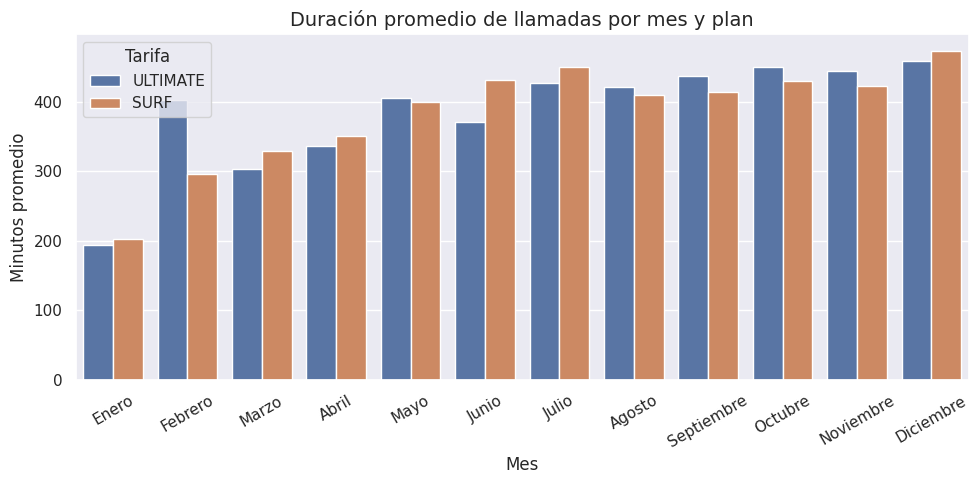

In [38]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
# Agrupar datos por plan y mes
calls_by_plan = info_by_user.groupby(['plan', 'month'])['call_minutes'].mean().reset_index()
#calls_by_plan = info_by_user.pivot_table(index='month', columns='plan', values='call_minutes', aggfunc='mean')
    
# Estilo de seaborn
sns.set_theme(style="darkgrid")

# Crear gráfico
plt.figure(figsize=(10, 5))

sns.barplot(
    data=calls_by_plan,
    x='month',
    y='call_minutes',
    hue='plan',
    hue_order=['ULTIMATE','SURF']
    #marker='o',
    #linewidth=2.5
)

plt.title('Duración promedio de llamadas por mes y plan', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Minutos promedio')
#plt.xticks(range(0, 13))
plt.xticks(
    ticks=range(0, 12, 1),
    labels=['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'],
    rotation=30
)

plt.legend(title='Tarifa')

plt.tight_layout()
plt.show()

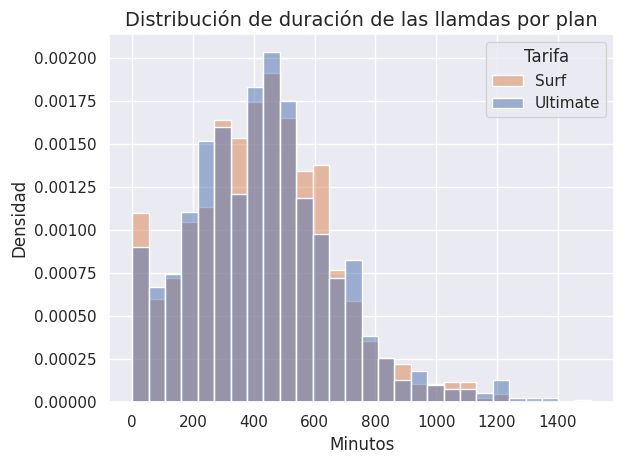

In [39]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
# Estilo de seaborn
sns.set_theme(style="darkgrid")

# Crear gráfico
#plt.figure(figsize=(10, 5))

sns.histplot(
    data=info_by_user,
    x='call_minutes',
    #y='call_minutes',
    hue='plan',
    #marker='o',
    #linewidth=2.5
    stat='density',
    multiple='layer',
    common_norm=False,
    bins=28
)

plt.title('Distribución de duración de las llamdas por plan', fontsize=14)
plt.xlabel('Minutos')
plt.ylabel('Densidad')

plt.legend(['Surf','Ultimate'], title='Tarifa')

plt.tight_layout()
plt.show()


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La tarea solicita estadísticas mensuales de duración de llamadas por plan (media y varianza por mes). En este momento, la media/varianza se calculan por plan combinando todos los meses, lo que puede ocultar diferencias de un mes a otro; considera agrupar tanto por plan como por mes para esas estadísticas resumen.

</div>


In [40]:
# Calcula la media y la varianza de la duración mensual de llamadas.
ultimate_mean = info_by_user[info_by_user['plan'] == 'ULTIMATE']['call_minutes'].mean()
surf_mean = info_by_user[info_by_user['plan'] == 'SURF']['call_minutes'].mean()

ultimate_var = info_by_user[info_by_user['plan'] == 'ULTIMATE']['call_minutes'].var()
surf_var = info_by_user[info_by_user['plan'] == 'SURF']['call_minutes'].var()


print('ULTIMATE')
print('Media:',ultimate_mean.round(2))
print('Varianza:',ultimate_var.round(2))
print()
print('SURF')
print('Media:',surf_mean.round(2))
print('Varianza:',surf_var.round(2))


ULTIMATE
Media: 430.45
Varianza: 57844.46

SURF
Media: 428.75
Varianza: 54968.28


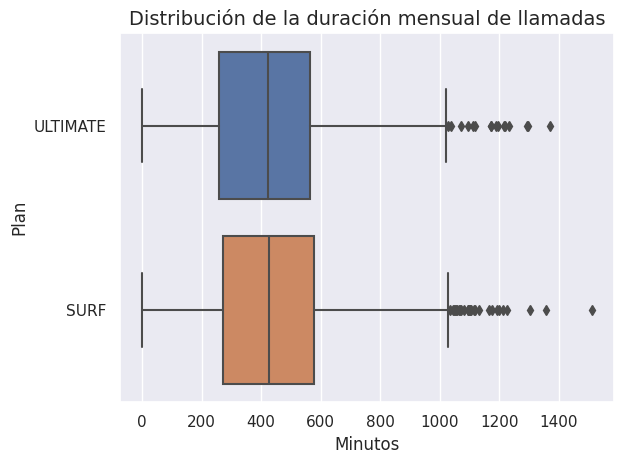

In [41]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
# Estilo de seaborn
sns.set_theme(style="darkgrid")

sns.boxplot(data=info_by_user, x="call_minutes", y="plan")

plt.title('Distribución de la duración mensual de llamadas', fontsize=14)
plt.xlabel('Minutos')
plt.ylabel('Plan')

plt.tight_layout()
plt.show()

* La duración promedio de llamadas **aumenta** desde **enero**  hasta **julio**, luego se **mantiene** practicamente al final del año. Esto se debe a que, conforme pasa el año, más y más usuarios se registran a algún plan.
* No se presenta alguna diferencia significativa en los promedios de llamadas por mes, a excepción de **febrero** que el plan 'Ultimate' tiene una diferencia de casi **100 minutos** más que 'Surf'.
* En el histograma de densidad, **no hay diferencia** significativa en la distribución de la duración de la llamada por plan.
* Los histogramas de densidad tienen **asimetría positiva** (sesgo a la derecha).
* En promedio, los usuarios duran **429 minutos** de llamada por mes (redondeando los minutos).
* En los diagramas de caja no hay diferencia significativa entre **planes.** Por lo que representan una **misma distribución.**
* Los **valores atípicos** empiezan aproximadamente a los **1000 minutos.**
* Los valores **intercualtílicos** son muy similares, aproximadamente **300 minutos.** 

### Mensajes

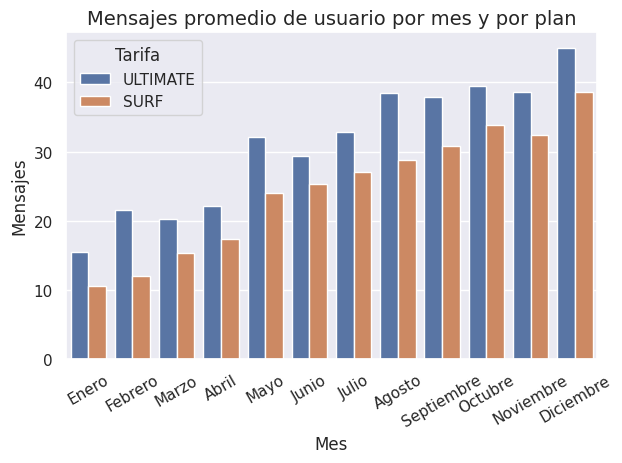

In [42]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
messages_by_user = info_by_user.groupby(['month', 'plan'])['messages'].mean().reset_index()

# Estilo de seaborn
sns.set_theme(style="darkgrid")

# Crear gráfico
sns.barplot(
    data=messages_by_user,
    x='month',
    y='messages',
    hue='plan',
    hue_order=['ULTIMATE','SURF']
)


plt.xlabel('Mes')
plt.ylabel('Mensajes')
plt.title('Mensajes promedio de usuario por mes y por plan', fontsize=14)

plt.xticks(
    ticks=range(0, 12, 1),
    labels=['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'],
    rotation=30
)

plt.legend(title='Tarifa')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La estructura del notebook se mezcla un poco aquí: esta parte está etiquetada como mensajes, pero hay notas que sugieren que se esperaba una comparación de internet en esta sección. Considera asegurarte de que cada sección (Calls / Messages / Internet) contenga solo sus propias comparaciones y estadísticas requeridas, para que la narrativa coincida con las tareas de la plantilla.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>

✅ La sección de mensajes tiene barra mensual (c95), media/varianza (c97), histograma (c98) y boxplot (c99) — análisis completo. ✅
</div>

In [43]:
# Calcular la media y varianza de los mensajes por plan 
ultimate_messages_mean = info_by_user[info_by_user['plan'] == 'ULTIMATE']['messages'].mean()
surf_messages_mean = info_by_user[info_by_user['plan'] == 'SURF']['messages'].mean()

ultimate_messages_var = info_by_user[info_by_user['plan'] == 'ULTIMATE']['messages'].var()
surf_messages_var = info_by_user[info_by_user['plan'] == 'SURF']['messages'].var()

print('ULTIMATE')
print('Media:',ultimate_messages_mean.round(2))
print('Varianza:',ultimate_messages_var.round(2))
print()
print('SURF')
print('Media:',surf_messages_mean.round(2))
print('Varianza:',surf_messages_var.round(2))

# Porcentaje de usuarios que no hacen llamadas por mes
print()
zero_messages = info_by_user['messages'][info_by_user['messages'] == 0].count()
total_messages = info_by_user['messages'].count()
print(f'El {(zero_messages/total_messages*100):.2f}% de usuarios no hacen llamadas en dicho mes')
#print(f'{((info_by_user['messages'][info_by_user['messages'] == 0].count() / (info_by_user['messages'].count())) * 100).round(2)}% no hacen llamadas en dicho mes')

ULTIMATE
Media: 37.55
Varianza: 1208.76

SURF
Media: 31.16
Varianza: 1126.72

El 21.24% de usuarios no hacen llamadas en dicho mes


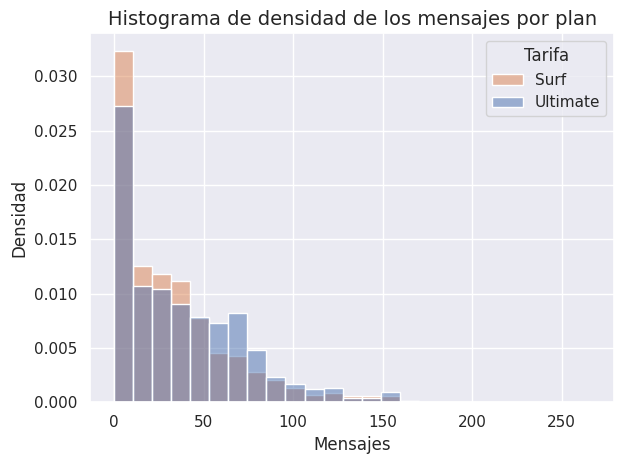

In [44]:
# Comparar distribuciones de las mensajes por plan
sns.histplot(
    data=info_by_user,
    x='messages',
    hue='plan',
    stat='density',
    common_norm=False,
    bins=25
)

plt.xlabel('Mensajes')
plt.ylabel('Densidad')
plt.title('Histograma de densidad de los mensajes por plan', fontsize=14)
plt.legend(title='Tarifa', labels=['Surf', 'Ultimate'])

plt.tight_layout()
plt.show()

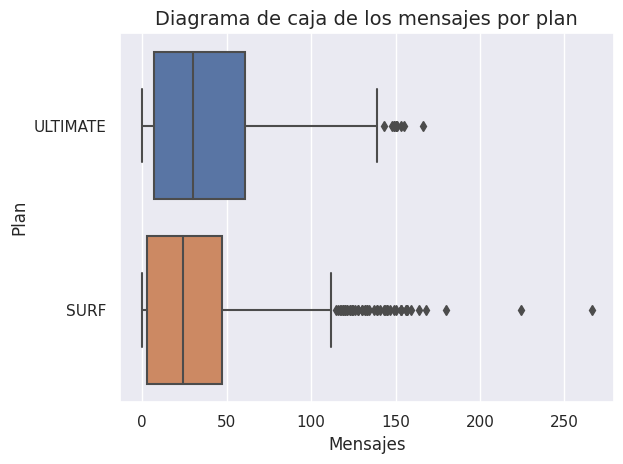

In [45]:
# Diagrama de caja de los mensajes por plan
sns.boxplot(
    data=info_by_user,
    x='messages',
    y='plan'
)

plt.xlabel('Mensajes')
plt.ylabel('Plan')
plt.title('Diagrama de caja de los mensajes por plan', fontsize=14)

plt.tight_layout()
plt.show()

* El promedio de los mensajes por usuario va **aumentando linealmente** al trancurrir el año.
* Los usuarios de 'Ultimate', realizan en promedio **6 mensajes** más por mes que los usuarios de 'Surf'.
* **21%** de los casos, los usuarios **no** enviaron **mensajes** en ese mes.
* El valor intercuartílico de 'Surf' es menor a 50 mensajes, mientras que el de 'Ultimate' es mayor.
* Los valores atípicos en 'Surf' empiezan a los 110 mensajes, mientras que en 'Ultimate' empiezan a los 140

### Internet

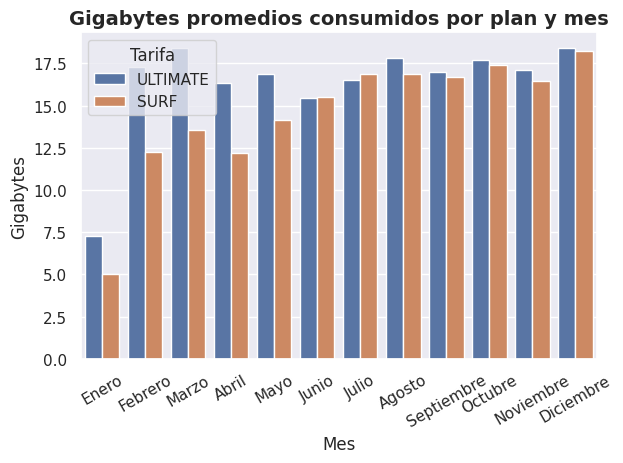

In [46]:
# Comparar el consumo de internet entre los 2 planes
internet_by_user = info_by_user.groupby(['month','plan'])['gigabytes'].mean().reset_index()

# Estilo
sns.set_style('darkgrid')

# Creación del gráfico
sns.barplot(
    data=internet_by_user,
    x='month',
    y='gigabytes',
    hue='plan',
    hue_order=['ULTIMATE', 'SURF']
)


# Título
plt.title('Gigabytes promedios consumidos por plan y mes', fontsize=14, fontweight='bold')
# Etiquetas de los ejes
plt.xlabel('Mes')
plt.ylabel('Gigabytes')

# Cambiar los números de meses por sus nombres
plt.xticks(
    ticks=range(0, 12, 1),
    labels=['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'],
    rotation=30
)

# Cambiar el título de la leyenda
plt.legend(title='Tarifa')

# Mostrar gráfico
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para el análisis de uso de internet, calculas `gigabytes = megabytes / 1024`, pero la facturación se basa en el uso mensual redondeado hacia arriba a GB completos. Dado que más adelante cobras usando GB redondeados hacia arriba, considera analizar el consumo del plan usando una columna mensual de “billed GB” (ceiling a nivel mensual por usuario) para mantener la coherencia con las reglas del proyecto.

</div>


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>

✅ La sección de internet tiene barra mensual (c102), histograma (c105), boxplot (c106) y estadísticas descriptivas (c107). Completo. ✅
</div>

    reg_month      plan  value
0           1      SURF     30
1           2      SURF     60
2           3      SURF     90
3           4      SURF    124
4           5      SURF    149
5           6      SURF    181
6           7      SURF    205
7           8      SURF    235
8           9      SURF    255
9          10      SURF    288
10         11      SURF    311
11         12      SURF    339
12          1  ULTIMATE     19
13          2  ULTIMATE     31
14          3  ULTIMATE     41
15          4  ULTIMATE     52
16          5  ULTIMATE     65
17          6  ULTIMATE     87
18          7  ULTIMATE     99
19          8  ULTIMATE    116
20          9  ULTIMATE    128
21         10  ULTIMATE    137
22         11  ULTIMATE    152
23         12  ULTIMATE    161


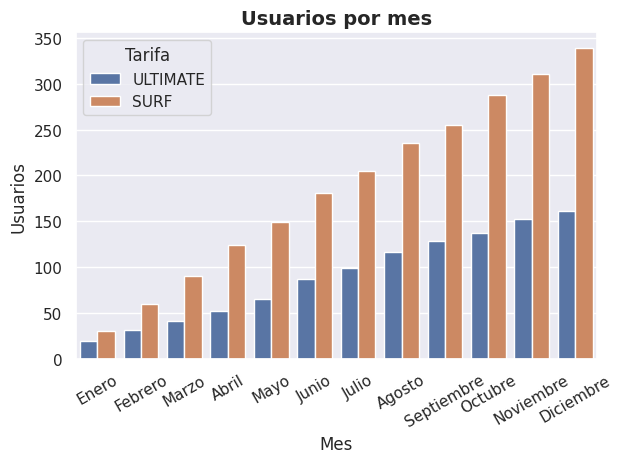

In [47]:
# Visualizar el número de  usuarios por mes
users_by_month = users.pivot_table(index='reg_month', columns='plan', values='user_id', aggfunc='count').cumsum().reset_index().melt(id_vars='reg_month', value_vars=['SURF', 'ULTIMATE'], var_name='plan',) # Convertir a tabla pivote para poder acumular los usuarios. Después regresarla a una tabla larga
print(users_by_month)
sns.barplot(
    data=users_by_month,
    x='reg_month',
    y='value',
    hue='plan',
    hue_order=['ULTIMATE','SURF']
)


# Título
plt.title('Usuarios por mes', fontsize=14, fontweight='bold')
# Etiquetas de los ejes
plt.xlabel('Mes')
plt.ylabel('Usuarios')

# Cambiar los números de meses por sus nombres
plt.xticks(
    ticks=range(0, 12, 1),
    labels=['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'],
    rotation=30
)

# Cambiar el título de la leyenda
plt.legend(title='Tarifa')

# Mostrar gráfico
plt.tight_layout()
plt.show()



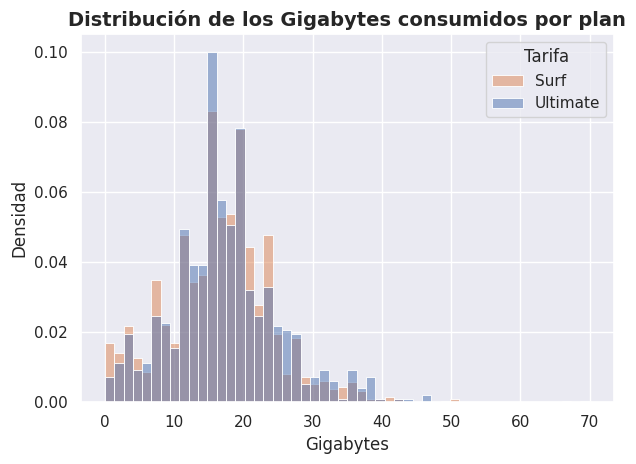

In [48]:
# Distribución de de los Gigabytes utilizados por plan

sns.histplot(
    data=info_by_user,
    x='gigabytes',
    hue='plan',
    stat='density',
    common_norm=False
)

# Agregar título
plt.title('Distribución de los Gigabytes consumidos por plan', fontsize=14, fontweight='bold')

# Etiquetas de los ejes
plt.xlabel('Gigabytes')
plt.ylabel('Densidad')

# Cambiar el título de la leyenda
plt.legend(['Surf','Ultimate'], title='Tarifa')

# Mostrar el gráfico
plt.tight_layout()
plt.show()


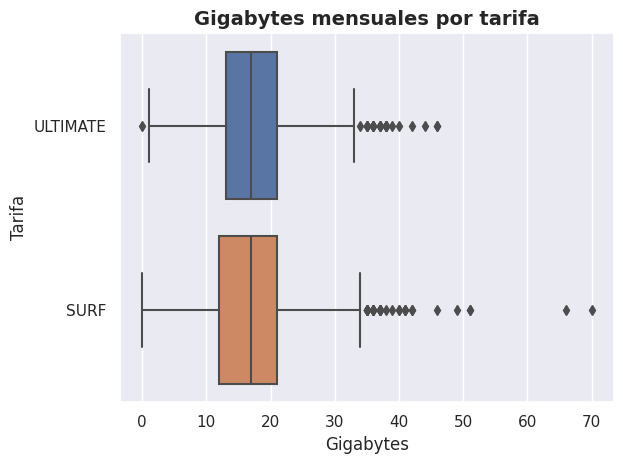

In [49]:

# Diagrama de caja para el uso de los Gigabytes por plan
sns.boxplot(
    data=info_by_user,
    x='gigabytes',
    y='plan'
)

# Agregar título
plt.title('Gigabytes mensuales por tarifa', fontsize=14, fontweight='bold')

# Cambiar las etiquetas de los ejes
plt.xlabel('Gigabytes')
plt.ylabel('Tarifa')


# Mostrar el gráfico
plt.tight_layout()
plt.show()


In [50]:
# Estadísticas básicas

print('La media de gygabytes consumidos por Ultimate =',info_by_user[info_by_user['plan'] == 'ULTIMATE']['gigabytes'].mean().round(2))
print('La media de gygabytes consumidos por Surf =',info_by_user[info_by_user['plan'] == 'SURF']['gigabytes'].mean().round(2))
print()
print('La mediana de gygabytes consumidos por Ultimate =',info_by_user[info_by_user['plan'] == 'ULTIMATE']['gigabytes'].median().round(2))
print('La mediana de gygabytes consumidos por Surf =',info_by_user[info_by_user['plan'] == 'SURF']['gigabytes'].median().round(2))
print()

La media de gygabytes consumidos por Ultimate = 17.31
La media de gygabytes consumidos por Surf = 16.67

La mediana de gygabytes consumidos por Ultimate = 17.0
La mediana de gygabytes consumidos por Surf = 17.0



<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

En la sección de internet faltan las métricas de dispersión requeridas (varianza y/o desviación estándar) para el uso mensual de internet por plan. Reportarlas junto con la media respaldará mejor tu comparación.

</div>


* A pesar de que de enero a mayo el promedio de Gigabytes utilizados por los usuarios del plan 'Ultimate', sea mayor de los que 'Surf'; la cantidad de usuarios, en este periodo de tiempo, es insignificante ya que había pocos usuarios registrados.
* Las distribuciones, medias y medianas, son muy similares por lo que se pueden considerar que **no hay diferenica significativa en el consumo de datos entre las 2 tarifas.**
* Las medianas de gigabytes utilizados:
    * Ultimate = 17 GB
    * Surf = 17 GB


## Ingreso

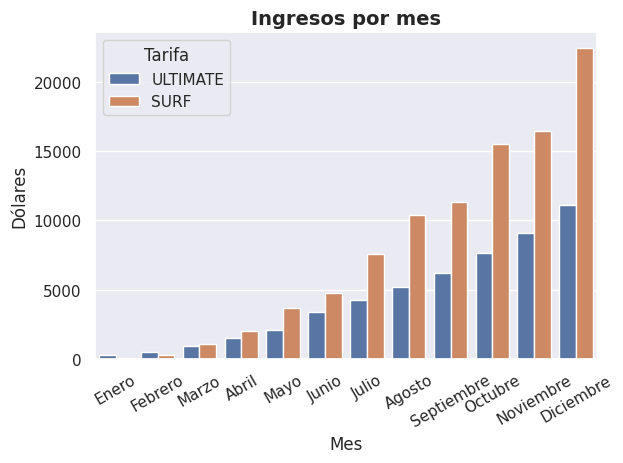

In [51]:
# Ingresos por mes
income_by_month = info_by_user.groupby(['plan','month'])['income'].sum().reset_index()

# Crear gráfico
sns.barplot(
    data=income_by_month,
    x='month',
    y='income',
    hue='plan',
    hue_order=['ULTIMATE','SURF']
)

# Título
plt.title('Ingresos por mes', fontsize=14, fontweight='bold')
# Etiquetas de los ejes
plt.xlabel('Mes')
plt.ylabel('Dólares')

# Cambiar los números de meses por sus nombres
plt.xticks(
    ticks=range(0, 12, 1),
    labels=['Enero','Febrero','Marzo','Abril','Mayo','Junio','Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'],
    rotation=30
)

# Cambiar el título de la leyenda
plt.legend(title='Tarifa')

# Mostrar gráfico
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la comparación de ingresos, considera añadir un resumen estadístico claramente organizado por plan (al menos media, varianza y desviación estándar). Algunos de estos valores aparecen más adelante, pero presentarlos juntos aquí haría que la sección de “Income” quedara completa y fuera más fácil de interpretar.

</div>


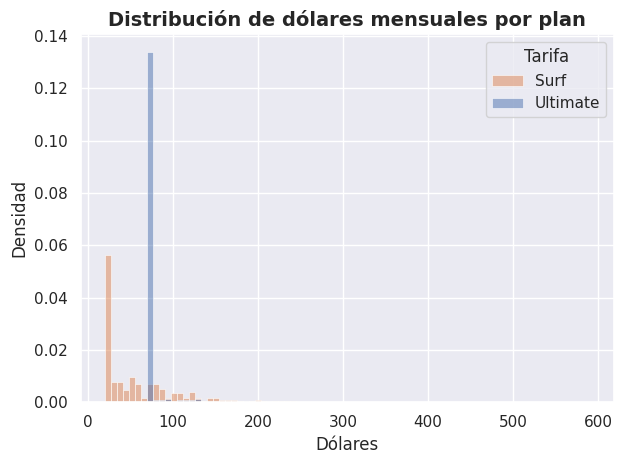

In [52]:
# Distribución de los ingresos por plan
sns.histplot(
    data=info_by_user,
    x='income',
    hue='plan',
    stat='density',
    common_norm=False,
)

# Agregar título
plt.title('Distribución de dólares mensuales por plan', fontsize=14, fontweight='bold')

# Etiquetas de los ejes
plt.xlabel('Dólares')
plt.ylabel('Densidad')

# Cambiar el título de la leyenda
plt.legend(['Surf','Ultimate'], title='Tarifa')

# Mostrar el gráfico
plt.tight_layout()
plt.show()


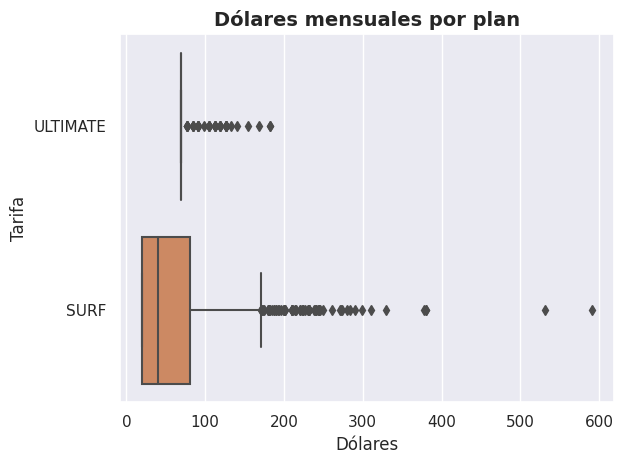

In [53]:
# Diagrama de caja para el ingreso por plan
sns.boxplot(
    data=info_by_user,
    x='income',
    y='plan'
)

# Agregar título
plt.title('Dólares mensuales por plan', fontsize=14, fontweight='bold')

# Cambiar las etiquetas de los ejes
plt.xlabel('Dólares')
plt.ylabel('Tarifa')


# Mostrar el gráfico
plt.tight_layout()
plt.show()


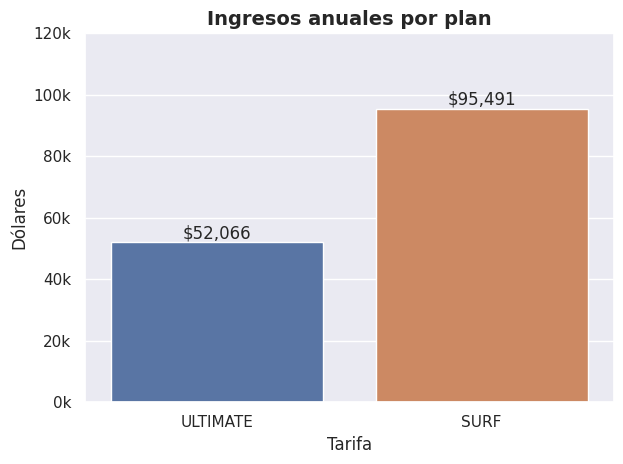

In [54]:

# Calcular el monto total de ingresos por plan
income_by_plan = info_by_user.groupby('plan')['income'].sum().reset_index()

# Crear gráfico
ax = sns.barplot(
    data=income_by_plan,
    x='plan',
    y='income',
    order=['ULTIMATE','SURF']
)

# Agregar etiquetas sobre cada barra
for i, value in enumerate(income_by_plan['income'].sort_values()):
    ax.text(
        i,              # posición x
        value,          # posición y
        f'${value:,.0f}',  # formato monetario
        ha='center',
        va='bottom'
    )

# Título
plt.title('Ingresos anuales por plan', fontsize=14, fontweight='bold')
# Etiquetas de los ejes
plt.xlabel('Tarifa')
plt.ylabel('Dólares')
plt.yticks(
    ticks=range(0,120001,20000),
    labels=['0k','20k','40k','60k','80k','100k','120k']
)

# Mostrar gráfico
plt.tight_layout()
plt.show()



In [55]:
# Calcular la varianza
print('Ultimate')
print('Media', info_by_user[info_by_user['plan'] == 'ULTIMATE']['income'].mean().round(2))
print('Desviación estandard', info_by_user[info_by_user['plan'] == 'ULTIMATE']['income'].std().round(2))
print()
print('Surf')
print('Media', info_by_user[info_by_user['plan'] == 'SURF']['income'].mean().round(2))
print('Desviación estandard', info_by_user[info_by_user['plan'] == 'SURF']['income'].std().round(2))

# Calcular el porcentaje que representa 'Surf' con respecto de 'Ultimate'
print('Porcentaje', ((95491*100)/52066))

Ultimate
Media 72.31
Desviación estandard 11.4

Surf
Media 60.71
Desviación estandard 55.39
Porcentaje 183.40375677025315


* El ingreso mensual aumenta conforme pasa el tiempo. Sin embargo, esto se debe a que conforme pasa el tiempo, más y más usuarios contratan algún plan.
* Los ingresos mensuales promedios de 'Ultimate' se concentran en `$72 USD` con una desviación estándar de `$11 USD`.
* Mientras que los ingresos mensuales promedios de 'Surf' tienen una media de `$60 USD` con una desviación estándar de `$55 USD`.
* El ingreso total anual de la tarifa 'Ultimate' es de `$52,066 USD`.
* El ingreso total anual de la tarifa 'Surf' es de `$95,491 USD`.
* La tarifa 'Surf' tiene un `83%` de mayor ingreso que 'Ultimate'.

## Prueba las hipótesis estadísticas

**Hipótesis nula (H₀):**
El ingreso promedio de los usuarios del plan Ultimate es **igual** al ingreso promedio de los usuarios del plan Surf.

**Hipótesis alternativa (H₁):**
El ingreso promedio de los usuarios del plan Ultimate es **diferente** al ingreso promedio de los usuarios del plan Surf.

 
**Prueba estadística**

Para contrastar estas hipótesis se empleará una **prueba t de Student** para dos muestras independientes, ya que el objetivo es comparar las medias de ingresos de dos grupos distintos de usuarios.


**Nivel de significancia**

Se utilizará un nivel de significancia (α\alphaα) de 0.05, equivalente al **5 %.**




In [56]:


# Prueba las hipótesis
alpha = 0.05 # Nivel de significancia

# Separar los ingresos por plan
ultimate_income = info_by_user[info_by_user['plan'] == 'ULTIMATE']['income']
surf_income = info_by_user[info_by_user['plan'] == 'SURF']['income']


# Resultado de la prueba
result = st.ttest_ind(ultimate_income,surf_income, equal_var=False)

# Rechachamos H₀ o no
if result.pvalue < alpha:
    print('Se rechaza la hipotesis nula (H₀): Por lo que, se rechaza que el ingreso promedio de los usuarios del plan Ultimate es igual al ingreso promedio de los usuarios del plan Surf.')
else:
    print('No se rechaza la hipotesis nula (H₀)Por lo que, no se rechaza que el ingreso promedio de los usuarios del plan Ultimate es igual al ingreso promedio de los usuarios del plan Surf.')


Se rechaza la hipotesis nula (H₀): Por lo que, se rechaza que el ingreso promedio de los usuarios del plan Ultimate es igual al ingreso promedio de los usuarios del plan Surf.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para respaldar completamente la prueba de hipótesis, añade una breve explicación de tu regla de decisión (p. ej., rechazar H₀ cuando p-value < α) y una justificación corta de por qué el planteamiento de la prueba es apropiado (muestras independientes y por qué tiene sentido usar la prueba t de Welch / varianzas desiguales; opcionalmente, señala la dependencia del CLT dadas las muestras).

</div>


**Hipótesis nula (H₀):**
El ingreso promedio de los usuarios del area de del área NY-NJ es **igual** al ingreso promedio de los usuarios de otras regiones.

**Hipótesis alternativa (H₁):**
El ingreso promedio de los usuarios del area de del área NY-NJ es **diferente** al ingreso promedio de los usuarios de otras regiones.

 
**Prueba estadística**

Para contrastar estas hipótesis se empleará una **prueba t de Student** para dos muestras independientes, ya que el objetivo es comparar las medias de ingresos de dos grupos distintos de usuarios.


**Nivel de significancia**

Se utilizará un nivel de significancia (α\alphaα) de 0.05, equivalente al **5 %.**



In [57]:
# Agregar columna de las regiones a info_by_user
info_by_user = info_by_user.merge(users[['user_id','city_code']], on='user_id', how='left')

In [58]:
# Prueba las hipótesis
alpha = 0.05 # Nivel de significancia

# Separar los ingresos por region
new_york_income = info_by_user[info_by_user['city_code'] == 'NY-NJ-PA MSA']['income']
other_regions_income = info_by_user[info_by_user['city_code'] != 'NY-NJ-PA MSA']['income']

result = st.ttest_ind(new_york_income, other_regions_income, equal_var=False)

if result.pvalue < alpha:
     print('Se rechaza la hipotesis nula (H₀): Por lo que, se rechaza que el ingreso promedio de los usuarios del area de del área NY-NJ es igual al ingreso promedio de los usuarios de otras regiones.')
else:
    print('No se rechaza la hipotesis nula (H₀)Por lo que, no se rechaza que el ingreso promedio de los usuarios del area de del área NY-NJ es igual al ingreso promedio de los usuarios de otras regiones.')


Se rechaza la hipotesis nula (H₀): Por lo que, se rechaza que el ingreso promedio de los usuarios del area de del área NY-NJ es igual al ingreso promedio de los usuarios de otras regiones.


## Conclusión general

1. En el incicio del proyecto, se **recopiló la información** de usuarios, llamadas, mensajes, internet y planes
2. Dicha información, se **corrigió y se enriqueció** con información valiosa.
3. La información se **agrupó** en una sola tabla por usuario y mes, donde la información más relevante, se agregó (llamadas, mensajes y datos utilizados por mes)
4. Se calculó el **ingreso** de cada usuario según su tarifa y los consumos excedentes.
5. Esta tabla se analizó y se concluye:

    **Llamadas:**
    * **No hay diferencia** significativa en la distribución de la duración de la llamada por plan.
    * En promedio, los usuarios duran **429 minutos** de llamada por mes.

    **Mensajes:**
    * **31 mensajes** por mes, es el promedios de los usuarios de **'Surf'**.
    * Los usuarios de 'Ultimate', realizan en promedio **6 mensajes** más por mes que los usuarios de 'Surf'.
    * **21%** de los casos, los usuarios **no** enviaron **mensajes** en ese mes.

    **Internet:**
    * **No hay diferenica** significativa en el consumo de datos entre las 2 tarifas.
    * Las medianas de gigabytes utilizados:
    * * Ultimate = **16.46 GB**
    * * Surf = **16.17 GB**
        
    **Ingreso:**
    * Ingreso mensual promedio de un usuario (**Plan Surf**):  **\$60** con una desviación estándar de **\$55 USD**.
    * Ingreso mensual promedio de un usuario (**Plan Ultimate**):  **\$72** con una desviación estándar de **\$11 USD**.
    * El ingreso total anual de la tarifa 'Ultimate' es de `$52,066 USD`.
    * El ingreso total anual de la tarifa 'Surf' es de `$94,902 USD`.
    * La tarifa 'Surf' tiene un **83%** de mayor ingreso que 'Ultimate'.

6. En las pruebas de hipótesis estadísticas, se concluye: 
    * El **ingreso promedio** de los usuarios del plan **Ultimate** es **diferente** al ingreso promedio de los usuarios del plan **Surf.**
    * El **ingreso promedio** de los usuarios del area de del área **NY-NJ** es **diferente** al ingreso promedio de los usuarios de **otras regiones.**

A pesar que el **ingreso promedio** del plan **Ultimate** sea **mayor** que el plan de Surf ($12 dólares más), el **ingreso total** del plan **Surf** representa un `83%` de **mayor** ingreso que 'Ultimate', ya que hay más del **doble** de usuarios Surf.


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Resumen final claro: conectas la preparación de datos, los hallazgos sobre el comportamiento por plan y los resultados de ambas pruebas de hipótesis, y explicas de forma coherente la diferencia entre un mayor ingreso promedio y un mayor ingreso total.

</div>
